In [4]:
import os
import argparse
import matplotlib.pyplot as plt
import scienceplots
from sklearn import manifold
from sklearn.decomposition import PCA
import numpy as np
# import torch
# import torch.nn as nn

# from models.TSMixer import Model
# from data_provider.data_factory import load_data

plt.style.use(['science', 'ieee'])
# plt.style.use(['science'])

In [5]:
def plot_3d(npz_path, mode='3d', plot_cbar=True, img_path=None):

    data = np.load(npz_path)
    features, targets = data['features'], data['targets']

    print(features.shape, targets.shape)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    if mode == '3d':
        sphere = ax.scatter3D(
            features[:, 0], features[:, 1], features[:, 2],
            c=targets, cmap='brg', vmin=np.min(targets), vmax=np.max(targets))
    elif mode == '2d':
        sphere = ax.scatter3D(
            features[:, 0], features[:, 1],
            c=targets, cmap='brg', vmin=np.min(targets), vmax=np.max(targets))
    else:
        sphere = ax.scatter3D(
            range(len(features)), features[:, 0],
            c=targets, cmap='brg', vmin=np.min(targets), vmax=np.max(targets))
        
    if plot_cbar:
        cbar = fig.colorbar(sphere, fraction=0.02)
        # start, end = (0.8, 1) if data_args.data in ['tri', 'mit'] else (0, 1)
        start, end = 0, 1
        cbar.mappable.set_clim(start, end)
        cbar.ax.minorticks_on()

    # ax.axis('off')
    # ax.set_xticks([-1, 0, 1], minor=True)
    # ax.set_yticks([-1, 0, 1], minor=True)
    # ax.set_zticks([-1, 0, 1], minor=True)

    # ax.grid(True)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    
    plt.tight_layout()
    plt.savefig(img_path, dpi=600)

(1024, 3) (1024,)
(1024, 3) (1024,)
(1024, 3) (1024,)


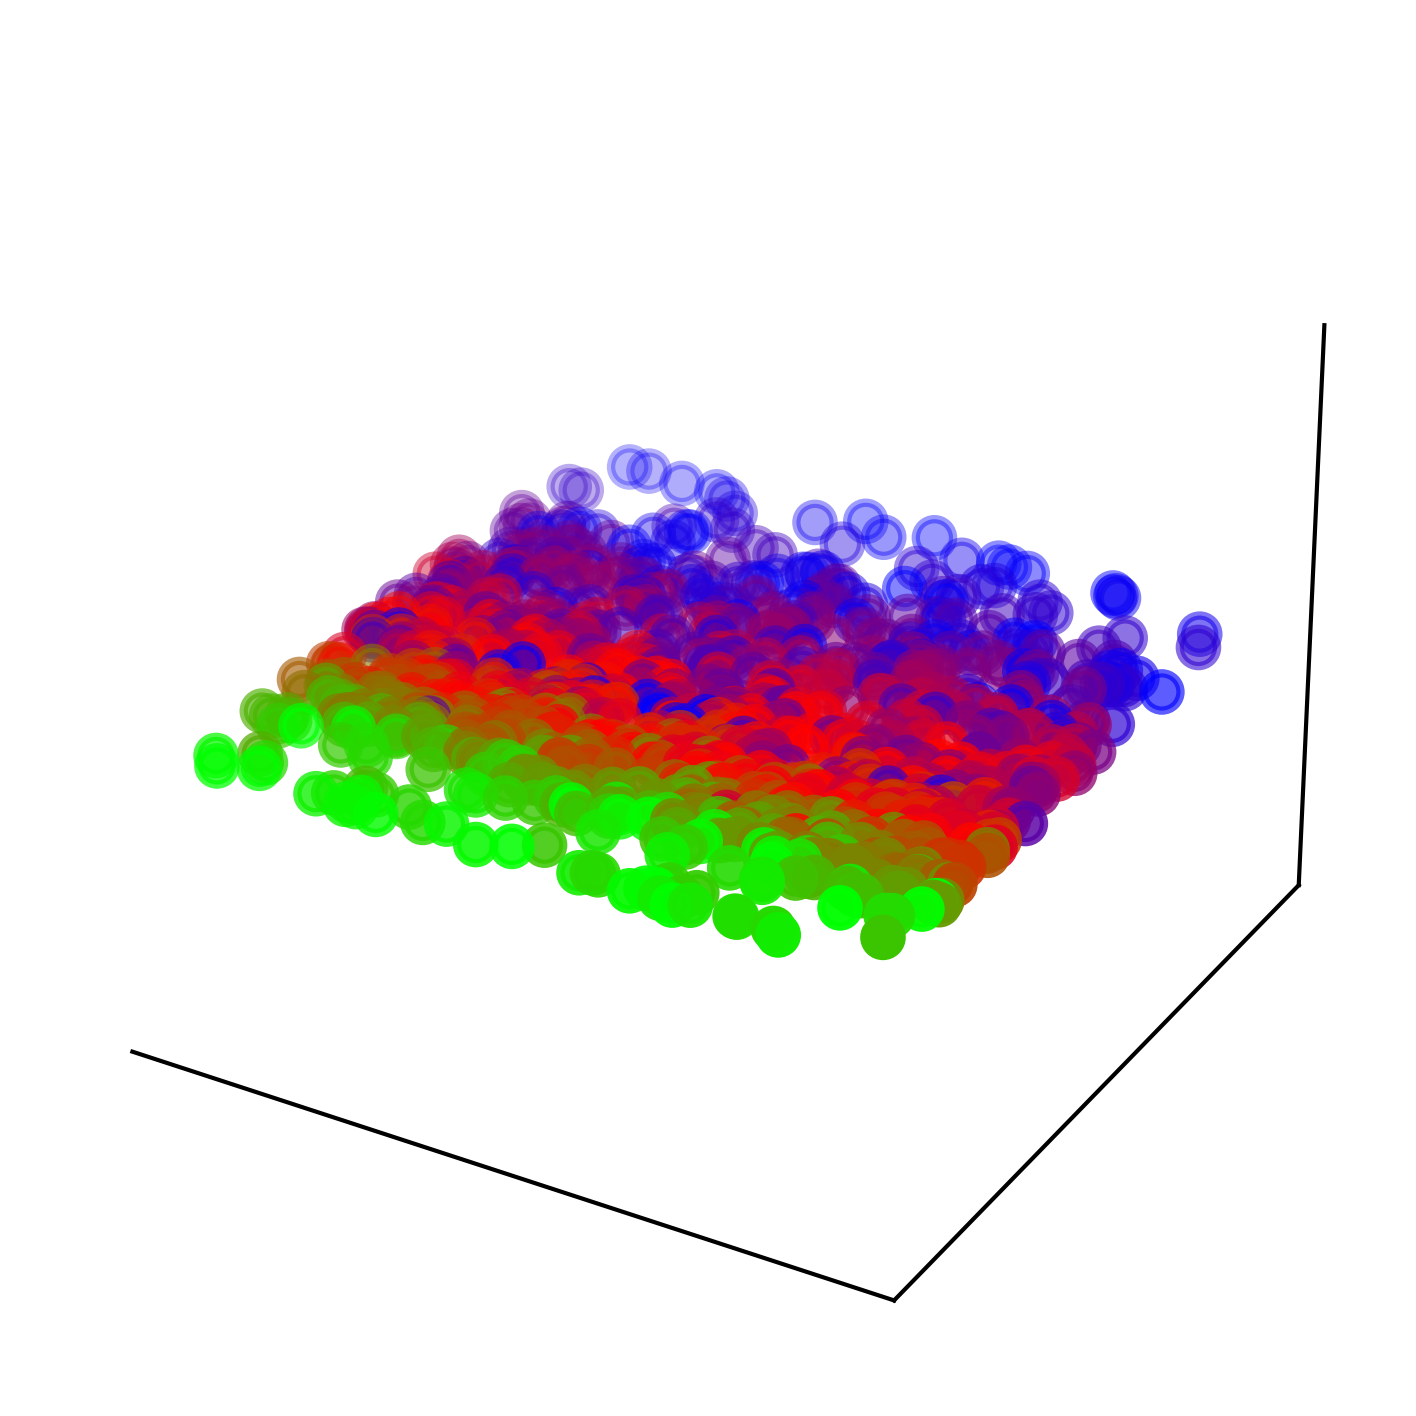

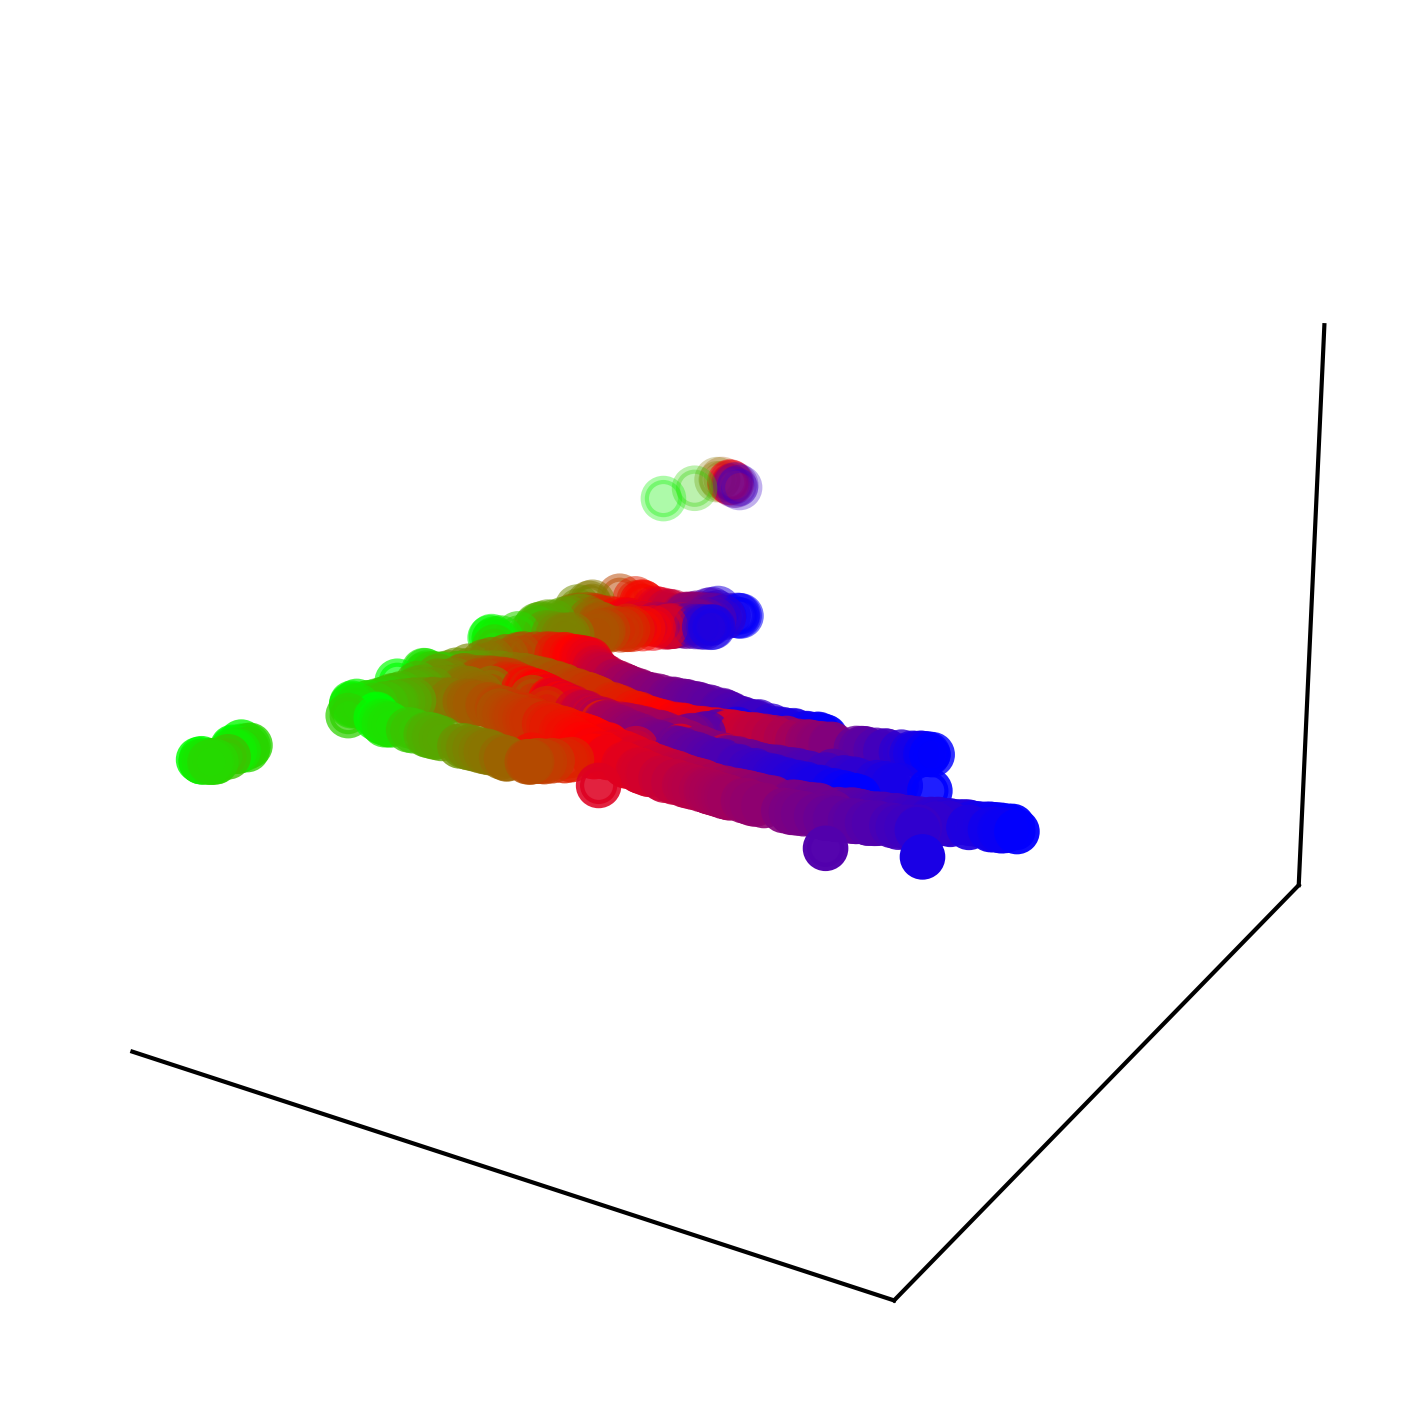

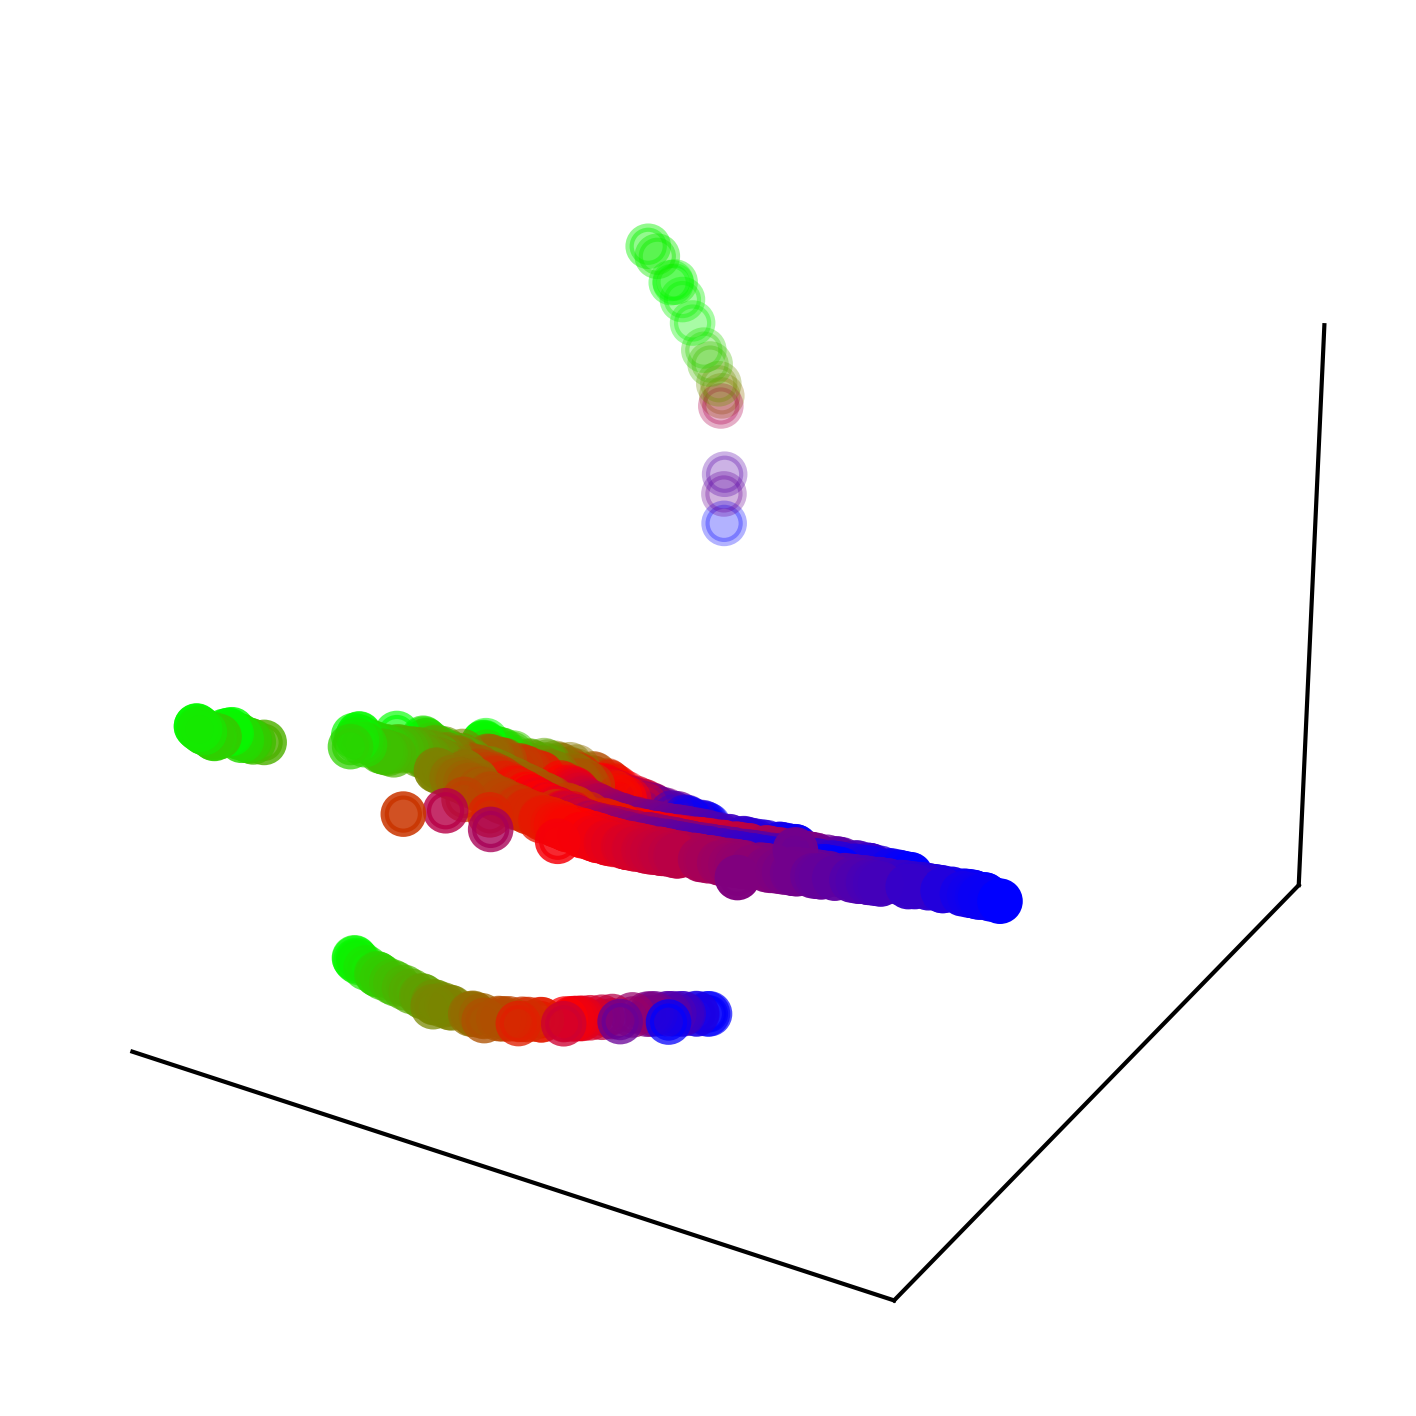

In [6]:
for mode in ['1d', '2d', '3d']:
    plot_3d(f'../../data/fig11_manifold/{mode}_tongji.npz', mode=mode, plot_cbar=False, img_path=f'./{mode}_tongji.png')